In [1]:
from pydantic import BaseModel
from openai import OpenAI
import os, sys
sys.path.insert(0, os.path.abspath(".."))
from src.rarekg.pubmed.pubmed_central import get_pmc_fulltext
from src.rarekg.sgr import (extract_entities, ExtractionResult)


pmcid = "PMC9314610"

title, abstract, para = get_pmc_fulltext(pmcid)
print(title)
print(abstract)







Genotype–phenotype correlates in Joubert syndrome: A review
Abstract Joubert syndrome (JS) is a genetically heterogeneous primary ciliopathy characterized by a pathognomonic cerebellar and brainstem malformation, the “molar tooth sign,” and variable organ involvement. Over 40 causative genes have been identified to date, explaining up to 94% of cases. To date, gene‐phenotype correlates have been delineated only for a handful of genes, directly translating into improved counseling and clinical care. For instance, JS individuals harboring pathogenic variants in TMEM67 have a significantly higher risk of liver fibrosis, while pathogenic variants in NPHP1 , RPGRIP1L , and TMEM237 are frequently associated to JS with renal involvement, requiring a closer monitoring of liver parameters, or renal functioning. On the other hand, individuals with causal variants in the CEP290 or AHI1 need a closer surveillance for retinal dystrophy and, in case of CEP290 , also for chronic kidney disease. These

In [3]:
from typing import Set, Tuple, Union, Dict, Any
import json


def _normalize_entity_name(name: str) -> str:
    """
    Very simple text normalization for comparison:
      - lowercase
      - strip leading/trailing whitespace
      - collapse internal whitespace

    You can later extend this (e.g. Greek letters, hyphens, punctuation).
    """
    name = name.strip().lower()
    # collapse multiple spaces/tabs/newlines
    parts = name.split()
    return " ".join(parts)


def _entities_from_json_like(
    data: Union[str, Dict[str, Any], ExtractionResult]
) -> Set[Tuple[str, str]]:
   
    if isinstance(data, ExtractionResult):
        ents = data.entities
        result: Set[Tuple[str, str]] = set()
        for e in ents:
            if hasattr(e.type, "value"):
                etype = e.type.value
            else:
                etype = str(e.type)
                if "." in etype:
                    etype = etype.split(".")[-1]

            if etype == "gene":
                name = e.name              # no normalization
            else:
                name = _normalize_entity_name(e.name)
            result.add((name, etype))
        return result
    
    if isinstance(data, str):
        data = json.loads(data)

    entities = data.get("entities", [])
    result: Set[Tuple[str, str]] = set()
    for ent in entities:
        name = ent.get("name")
        etype = ent.get("type")
        if not name or not etype:
            continue
        if etype == "gene":
            norm_name = name  # keep as is
        else:
            norm_name = _normalize_entity_name(name)

        result.add((norm_name, str(etype)))
    return result


def evaluate_extraction(
    gold: Union[str, Dict[str, Any], ExtractionResult],
    pred: Union[str, Dict[str, Any], ExtractionResult],
) -> Dict[str, float]:
    gold_set = _entities_from_json_like(gold)
    pred_set = _entities_from_json_like(pred)

    tp = len(gold_set & pred_set)
    fp = len(pred_set - gold_set)
    fn = len(gold_set - pred_set)

    num_gold = len(gold_set)
    num_pred = len(pred_set)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "true_positives": float(tp),
        "false_positives": float(fp),
        "false_negatives": float(fn),
        "num_gold": float(num_gold),
        "num_pred": float(num_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


In [18]:
print(para[20])

Neurodevelopmental features in JS are related to the underlying brain malformation and, as such, represent constant features of the syndrome, and usually the earliest to manifest. These consist in neonatal hypotonia, abnormal eye movements (mainly ocular motor apraxia, OMA), and breathing dysregulation (apneas and/or hyperpneas usually resolving within few months of life). A delay of developmental milestones becomes evident soon after, followed by ataxia (with broad‐based, unsteady gait and difficulties in running or climbing stairs) and intellectual disability of variable severity; nevertheless, a minority of individuals have borderline, or even normal cognitive functions (Bulgheroni et al., 2016 ; Poretti, Alber, Bürki, Toelle, & Boltshauser, 2009 ; Summers et al., 2017 ). Notably, Poretti et al. reported that neuroimaging may predict the neurodevelopmental outcome, as a high degree of vermis hypoplasia was found to correlate with worse prognosis (Poretti et al., 2017 ). Of note, exp

In [4]:
client = OpenAI(base_url="http://localhost:8000/v1", api_key="dummy")

In [5]:
import re

# Very simple pattern: parentheses with at least one 4-digit year
CITATION_RE = re.compile(
    r"\((?:[^()]*?\d{4}[^()]*)\)"
)

def strip_inline_citations(text: str) -> str:
    return CITATION_RE.sub("", text)

ETAL_RE = re.compile(r"\b[A-Z][a-z]+ et al\.\b")

def strip_citation_like_bits(text: str) -> str:
    text = CITATION_RE.sub("", text)
    text = ETAL_RE.sub("", text)
    return text


In [12]:
from src.rarekg.sgr import (SGR_RD_PROMPT, SGR_Pheno_PROMPT, SGR_treatment_PROMPT)
text = strip_citation_like_bits(abstract)
pred_rd = extract_entities(
    text,
    client,
    model="medgemma",
    system_prompt= SGR_RD_PROMPT,
    use_response_format=False,   # vLLM: use guided_json
)
pred_pheno = extract_entities(
    text,
    client,
    model="medgemma",
    system_prompt= SGR_Pheno_PROMPT,
    use_response_format=False,   # vLLM: use guided_json
)
result = _entities_from_json_like(pred_rd) | _entities_from_json_like(pred_pheno)
pred_treatment = extract_entities(
    text,
    client,
    model="medgemma",
    system_prompt= SGR_treatment_PROMPT,
    use_response_format=False,   # vLLM: use guided_json
)

result = result | _entities_from_json_like(pred_treatment)



print (result)

{('NPHP1', 'gene'), ('TMEM237', 'gene'), ('RPGRIP1L', 'gene'), ('TMEM67', 'gene'), ('CEP290', 'gene'), ('joubert syndrome', 'rare_disease'), ('AHI1', 'gene'), ('molar tooth sign', 'phenotype')}


In [ ]:
 metrics = evaluate_extraction(, result)
    total_tp_m += metrics["true_positives"]
    total_fp_m += metrics["false_positives"]
    total_fn_m += metrics["false_negatives"]

precision_m = total_tp_m/ (total_tp_m+ total_fp_m) if (total_tp_m+ total_fp_m) > 0 else 0.0
recall_m    = total_tp_m/ (total_tp_m+ total_fn_m) if (total_tp_m+ total_fn_m) > 0 else 0.0
f1_m = (
    2 * precision_m * recall_m / (precision_m + recall_m)
    if (precision_m + recall_m) > 0
    else 0.0
)

print("Precision:", precision_m)
print("Recall:", recall_m)
print("F1:", f1_m)

In [7]:
from pathlib import Path
import json

golden_dir = Path("../golden")

total_tp_m = total_fp_m = total_fn_m = 0

for i in range(0, 14):  
    path = golden_dir / f"para_{i}.json" 

    if not path.exists():
        print(f"Missing file: {path}")
        continue

    with path.open("r", encoding="utf-8") as f:
        gold = json.load(f)

    if i == 0:
        text = strip_citation_like_bits(abstract)
        pred_i_json = extract_entities(
            text,
            client,
            model="medgemma",
            system_prompt= sgr_all,
            use_response_format=False,   # vLLM: use guided_json
        )
    elif 1<=i<=3:
        text = strip_citation_like_bits(para[i-1])
        pred_i_json = extract_entities(
        text,
        client,
        model="medgemma",
        system_prompt= sgr_all,
        use_response_format=False,   # vLLM: use guided_json
    )
    else:
        text = strip_citation_like_bits(para[i+6])
        pred_i_json = extract_entities(
        text,
        client,
        model="medgemma",
        system_prompt= sgr_all,
        use_response_format=False,   # vLLM: use guided_json
    )
        
    print(i)
    print(_entities_from_json_like(pred_i_json))
    print(_entities_from_json_like(gold))
    metrics = evaluate_extraction(gold, pred_i_json)
    total_tp_m += metrics["true_positives"]
    total_fp_m += metrics["false_positives"]
    total_fn_m += metrics["false_negatives"]

precision_m = total_tp_m/ (total_tp_m+ total_fp_m) if (total_tp_m+ total_fp_m) > 0 else 0.0
recall_m    = total_tp_m/ (total_tp_m+ total_fn_m) if (total_tp_m+ total_fn_m) > 0 else 0.0
f1_m = (
    2 * precision_m * recall_m / (precision_m + recall_m)
    if (precision_m + recall_m) > 0
    else 0.0
)

print("Precision:", precision_m)
print("Recall:", recall_m)
print("F1:", f1_m)

0
{('NPHP1', 'gene'), ('TMEM237', 'gene'), ('RPGRIP1L', 'gene'), ('TMEM67', 'gene'), ('CEP290', 'gene'), ('joubert syndrome', 'rare_disease'), ('AHI1', 'gene'), ('molar tooth sign', 'phenotype')}
{('NPHP1', 'gene'), ('TMEM237', 'gene'), ('liver fibrosis', 'phenotype'), ('retinal dystrophy', 'phenotype'), ('TMEM67', 'gene'), ('cerebellar malformation', 'phenotype'), ('RPGRIP1L', 'gene'), ('CEP290', 'gene'), ('joubert syndrome', 'rare_disease'), ('AHI1', 'gene'), ('brainstem malformation', 'phenotype'), ('molar tooth sign', 'phenotype'), ('chronic kidney disease', 'phenotype')}
1
{('vermian dysplasia', 'phenotype'), ('superior cerebellar peduncles', 'phenotype'), ('interpeduncular fossa', 'phenotype'), ('joubert syndrome', 'rare_disease'), ('molar tooth sign', 'phenotype'), ('midbrain–hindbrain junction', 'phenotype'), ('cerebellar hypoplasia', 'phenotype')}
{('horizontally oriented superior cerebellar peduncles', 'phenotype'), ('abnormally deep interpeduncular fossa', 'phenotype'), ('ve

In [9]:
import matplotlib.pyplot as plt

def plot_prf(precision, recall, f1, model_name="Model"):
    metrics = ["Precision", "Recall", "F1"]
    values = [precision, recall, f1]

    x = range(len(metrics))  

    plt.figure(figsize=(8, 5))
    plt.bar(x, values, width=0.3)  

    plt.ylim(0, 1.0)
    plt.xticks(x, metrics)
    plt.ylabel("Score")
    plt.title(f"Entity Extraction ({model_name}): Precision / Recall / F1")
    plt.tight_layout()
    plt.show()

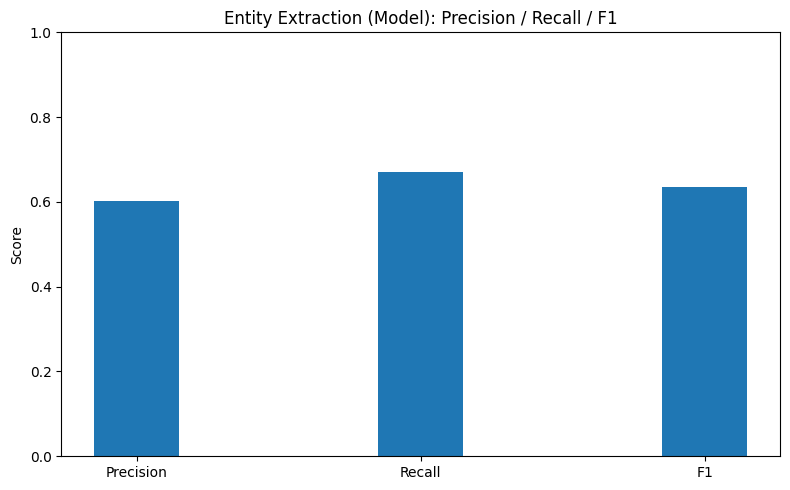

In [10]:
plot_prf(precision_m,recall_m, f1_m)

1
{('superior cerebellar peduncles', 'phenotype'), ('interpeduncular fossa', 'phenotype'), ('cerebellar hypoplasia', 'phenotype'), ('joubert syndrome (js)', 'rare_disease'), ('molar tooth sign', 'phenotype'), ('vermian dysplasia', 'phenotype')}
{('thick superior cerebellar peduncles', 'phenotype'), ('brainstem malformations', 'phenotype'), ('joubert syndrome', 'rare_disease'), ('malformation of the midbrain–hindbrain junction', 'phenotype'), ('cerebellar hypoplasia', 'phenotype'), ('horizontally oriented superior cerebellar peduncles', 'phenotype'), ('cerebellar malformations', 'phenotype'), ('molar tooth sign', 'phenotype'), ('vermian dysplasia', 'phenotype'), ('abnormally deep interpeduncular fossa', 'phenotype')}
2
{('ocular motor apraxia', 'phenotype'), ('cognitive impairment', 'phenotype'), ('joubert syndrome', 'rare_disease'), ('hypotonia', 'phenotype'), ('episodic breathing dysregulation', 'phenotype'), ('cerebellar ataxia', 'phenotype'), ('facial dysmorphisms', 'phenotype'), ('

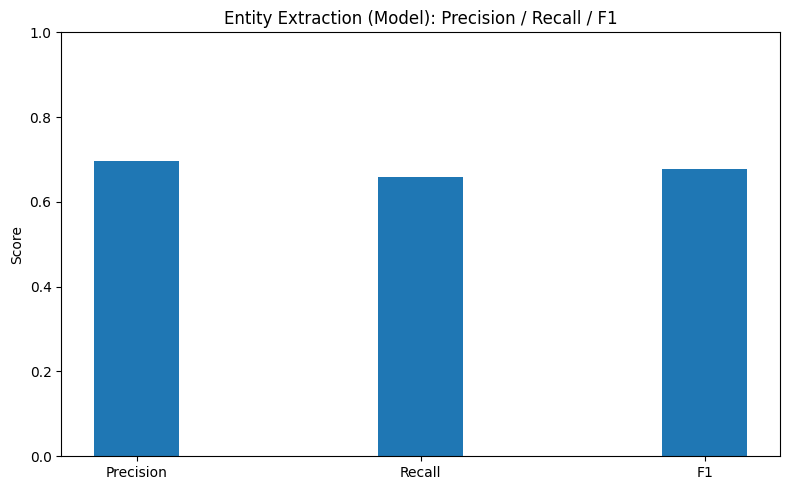

In [42]:
from pathlib import Path
import json

golden_dir = Path("../golden")

total_tp_l= total_fp_l= total_fn_l= 0

for i in range(1, 14):  
    path = golden_dir / f"para_{i}.json" 

    if not path.exists():
        print(f"Missing file: {path}")
        continue

    with path.open("r", encoding="utf-8") as f:
        gold = json.load(f)

    if i == 0:
        pred_i_json = extract_entities(
            abstract,
            client,
            model="llama",
            system_prompt= sgr_all,
            use_response_format=False,   # vLLM: use guided_json
        )
        
    elif 1<=i<=3:
        pred_i_json = extract_entities(
        para[i-1],
        client,
        model="llama",
        system_prompt= sgr_all,
        use_response_format=False,   # vLLM: use guided_json
    )
    else:
        pred_i_json = extract_entities(
        para[i+6],
        client,
        model="llama",
        system_prompt= sgr_all,
        use_response_format=False,   # vLLM: use guided_json
    )
        
    print(i)
    print(_entities_from_json_like(pred_i_json))
    print(_entities_from_json_like(gold))
    metrics = evaluate_extraction(gold, pred_i_json)
    total_tp_l+= metrics["true_positives"]
    total_fp_l+= metrics["false_positives"]
    total_fn_l+= metrics["false_negatives"]


precision_l = total_tp_l/ (total_tp_l+ total_fp_l) if (total_tp_l+ total_fp_l) > 0 else 0.0
recall_l    = total_tp_l/ (total_tp_l+ total_fn_l) if (total_tp_l+ total_fn_l) > 0 else 0.0
f1_l= (
    2 * precision_l * recall_l / (precision_l + recall_l)
    if (precision_l + recall_l) > 0
    else 0.0
)

print("Precision:", precision_l)
print("Recall:", recall_l)
print("F1:", f1_l)
plot_prf(precision_l,recall_l, f1_l)



In [9]:
print(pmcid)

PMC9314610


In [15]:
id = pmcid.split("PMC")[1]
print(id)

9314610


In [31]:
pmcids = ["PMC9437135", "PMC8901527" , "PMC12021325", "PMC4289844", "PMC10032320", "PMC10401045", "PMC9314610", "PMC9167473", "PMC7531107", "PMC2783042", "PMC9278302", "PMC7702659", "PMC3014844", "PMC5717851", "PMC8488375" ]

In [34]:
pmids = ["35655331", "34826654", "39435720", "25578972", "36803942", "37547106", "35238134", "35721635", "33004012", "19946579", "35452508", "32618441", "21209736", "29208045", "34616357"]

In [38]:
import requests
from typing import List, Dict, Any

PUBTATOR_EXPORT_URL = (
    "https://www.ncbi.nlm.nih.gov/research/pubtator3-api/publications/export/biocjson"
)


def fetch_pubtator_docs(pmids: List[str], full: bool = True) -> List[Dict[str, Any]]:
    """
    Fetch BioC-JSON annotations from PubTator3 for a list of PMIDs.
    """
    params = {
        "pmids": ",".join(str(p) for p in pmids),
    }
    if full:
        params["full"] = "true"  # include full text when available

    resp = requests.get(PUBTATOR_EXPORT_URL, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()

    # PubTator3 usually wraps docs under top-level key "PubTator3"
    if isinstance(data, dict) and "PubTator3" in data:
        return data["PubTator3"]
    elif isinstance(data, list):
        return data
    else:
        raise ValueError(f"Unexpected response shape: {type(data)}")


# def parse_entities_from_doc(doc: Dict[str, Any]) -> Dict[str, list]:
#     """
#     Extract genes, diseases, chemicals (drugs), and variants from a single document.
#     Returns lists of dicts with surface text, id, section, offsets, etc.
#     """
#     entities = {
#         "genes": [],
#         "diseases": [],
#         "chemicals": [],
#     }

#     for passage in doc.get("passages", []):
#         section = passage.get("infons", {}).get("section_type", "")
#         for ann in passage.get("annotations", []):
#             text = ann.get("text")
#             if not text:
#                 continue

#             infons = ann.get("infons", {})
#             ent_type = infons.get("type")  # e.g. Gene, Disease, Chemical, Variant
#             identifier = infons.get("identifier")  # e.g. NCBIGene:672, MESH:D009369, etc.

#             locs = ann.get("locations", [])
#             start = locs[0]["offset"] if locs else None
#             length = locs[0]["length"] if locs else None

#             record = {
#                 "text": text,
#                 "identifier": identifier,
#                 "raw_type": ent_type,
#                 "section": section,
#                 "offset": start,
#                 "length": length,
#             }

#             if ent_type in ("Gene", "Protein"):
#                 entities["genes"].append(record)
#             elif ent_type == "Disease":
#                 entities["diseases"].append(record)
#             elif ent_type in ("Chemical", "Drug"):
#                 entities["chemicals"].append(record)

#     return entities
from typing import Dict, List, Any


def _normalize_mention(text: str) -> str:
    """Normalize disease/chemical text for deduplication."""
    # lowercase + collapse multiple spaces
    return " ".join(text.lower().split())


def parse_entities_from_doc(doc: Dict[str, Any]) -> Dict[str, List[Dict[str, Any]]]:
    """
    Extract genes, diseases, and chemicals (drugs) from a single PubTator3 document.

    - Genes: keep as-is (no normalization, no dedup).
    - Diseases & chemicals: deduplicate by normalized text (case-insensitive).
    """
    entities: Dict[str, List[Dict[str, Any]]] = {
        "genes": [],
        "diseases": [],
        "chemicals": [],
    }

    # Track which normalized texts we've already added
    seen_diseases: set[str] = set()
    seen_chemicals: set[str] = set()
    seen_genes: set[str] = set()

    for passage in doc.get("passages", []):
        section = passage.get("infons", {}).get("section_type", "")
        for ann in passage.get("annotations", []):
            text = ann.get("text")
            if not text:
                continue

            infons = ann.get("infons", {})
            ent_type = infons.get("type")          # e.g. "Gene", "Disease", "Chemical"
            identifier = infons.get("identifier")  # e.g. "NCBIGene:672", "MESH:D009369"

            locs = ann.get("locations", [])
            start = locs[0]["offset"] if locs else None
            length = locs[0]["length"] if locs else None

            record = {
                "text": text,
                "identifier": identifier,
                "raw_type": ent_type,
                "section": section,
                "offset": start,
                "length": length,
            }

            # --- Genes: only type == "Gene", no Protein, no normalization/dedup ---
            if ent_type == "Gene":
                if text not in seen_genes:
                    seen_genes.add(text)
                    entities["genes"].append(record)

            # --- Diseases: dedup by normalized surface text ---
            elif ent_type == "Disease":
                norm = _normalize_mention(text)
                if norm not in seen_diseases:
                    seen_diseases.add(norm)
                    entities["diseases"].append(record)

            # --- Chemicals: dedup by normalized surface text ---
            elif ent_type in ("Chemical", "Drug"):
                norm = _normalize_mention(text)
                if norm not in seen_chemicals:
                    seen_chemicals.add(norm)
                    entities["chemicals"].append(record)

    return entities



def get_pubtator_entities_for_pmids(pmids: List[str], full: bool = True) -> Dict[str, Dict[str, list]]:
    """
    High-level helper:
    returns { pmid: {genes: [...], diseases: [...], chemicals: [...], variants: [...] } }
    """
    docs = fetch_pubtator_docs(pmids, full=full)
    results: Dict[str, Dict[str, list]] = {}

    for doc in docs:
        # PMID is usually stored in doc["infons"]["article-id_pmid"]
        infons = doc.get("infons", {})
        pmid = infons.get("article-id_pmid") or infons.get("pmid")

        if not pmid:
            # fallback: split _id like "29355051|PMC6142073"
            _id = doc.get("_id", "")
            pmid = _id.split("|")[0] if "|" in _id else _id

        results[str(pmid)] = parse_entities_from_doc(doc)

    return results


if __name__ == "__main__":
    entities_by_pmid = get_pubtator_entities_for_pmids(pmids, full=True)

    for pmid, ents in entities_by_pmid.items():
        print("PMID:", pmid)
        print("  Genes:")
        for g in ents["genes"]:
            print("    -", g["text"], g["identifier"])
        print("  Diseases:")
        for d in ents["diseases"]:
            print("    -", d["text"], d["identifier"])
        print("  Chemicals (candidate drugs):")
        for c in ents["chemicals"]:
            print("    -", c["text"], c["identifier"])
        print()


PMID: 19946579
  Genes:
    - renin 5972
    - parathyroid hormone 5741
    - erythropoietin 2056
    - insulin 3630
    - PTH 5741
  Diseases:
    - De Toni-Debre-Fanconi syndrome MESH:D005198
    - Kearns-Sayre syndrome MESH:D007625
    - pigmentary degeneration of the retina MESH:D007625
    - ophthalmoplegia MESH:D009886
    - mitochondrial myopathy MESH:D017240
    - glucosuria MESH:D006030
    - diabetes mellitus MESH:D003920
    - external ophthalmoplegia MESH:D009886
    - hyperaldosteronism MESH:D006929
    - sensorineural hearing impairment MESH:D006319
    - palpebral ptosis MESH:C564553
    - hyperaminoaciduria None
    - cardiac conduction defect MESH:D000075224
    - cerebellar ataxia MESH:D002524
    - hypoparathyroidism MESH:D007011
    - myopathy MESH:D009135
    - short stature MESH:D006130
    - hyperphosphaturia MESH:D007015
    - insufficiency of the renal tubule MESH:D051437
    - pigmentary retinopathy MESH:D012174
    - mitochondrial diseases MESH:D028361
    - 

In [32]:

from pathlib import Path

for pmcid in pmcids:
    title, abstract, para = get_pmc_fulltext(pmcid)
    input_dir = Path("../PhenoTagger_v1.2/input")
    input_dir.mkdir(parents=True, exist_ok=True)
    with open(input_dir /f"{pmcid}.PubTator", "w", encoding="utf-8") as f:
        f.write(f"{id}|t|{title}\n")
        f.write(f"{id}|a|{abstract}\n")
        for i in range(0, (len(para)-1)):
            f.write(f"{id}|p|{para[i]}\n")

In [ ]:
import re
from pathlib import Path
from typing import List

def highlight_phrases_html(
    text: str,
    phrases: List[str],
    color_name: str = "green",
    output_path: str = "highlighted.html",
) -> Path:
    """
    Highlight all occurrences of the given phrases in `text` with the given color
    and write an HTML file.

    Parameters
    ----------
    text : str
        Original text.
    phrases : list[str]
        Phrases to highlight (as they appear in the text).
    color_name : str
        Simple colour name such as "green", "red", "blue", "yellow".
        This will be mapped to a soft background colour.
    output_path : str
        Output HTML file path.

    Returns
    -------
    Path
        Path to the written HTML file.
    """

    # Map simple names to nice soft CSS colours
    palette = {
        "green":  "#d1ffd8",
        "red":    "#ffd1d1",
        "blue":   "#d1e7ff",
        "yellow": "#fff7c2",
        "purple": "#e4d1ff",
    }
    bg_color = palette.get(color_name.lower(), color_name)  # fallback: use as-is

    # Non-overlapping spans
    spans = []              # (start, end)
    taken = [False] * len(text)

    # Sort phrases by length so longer phrases win
    for phrase in sorted(set(phrases), key=len, reverse=True):
        if not phrase:
            continue
        pattern = re.escape(phrase)
        for m in re.finditer(pattern, text):
            start, end = m.start(), m.end()
            if any(taken[start:end]):
                continue
            for i in range(start, end):
                taken[i] = True
            spans.append((start, end))

    spans.sort(key=lambda x: x[0])

    def escape_html(s: str) -> str:
        return (
            s.replace("&", "&amp;")
             .replace("<", "&lt;")
             .replace(">", "&gt;")
        )

    html_parts = []
    last = 0
    for start, end in spans:
        if start > last:
            html_parts.append(escape_html(text[last:start]))
        chunk = escape_html(text[start:end])
        html_parts.append(
            f'<span style="background-color:{bg_color};">{chunk}</span>'
        )
        last = end

    if last < len(text):
        html_parts.append(escape_html(text[last:]))

    body = "".join(html_parts)

    html_doc = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Highlighted text</title>
</head>
<body>
<p>{body}</p>
</body>
</html>
"""

    path = Path(output_path)
    path.write_text(html_doc, encoding="utf-8")
    return path
